In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("btcusd_1-min_data.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7464640 entries, 0 to 7464639
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 341.7 MB


In [3]:
df["datetime"] = pd.to_datetime(df["Timestamp"], unit="s")

df = df.drop("Timestamp", axis=1)

df = df.set_index("datetime")

df = df.sort_index()

df.index

DatetimeIndex(['2012-01-01 10:01:00', '2012-01-01 10:02:00',
               '2012-01-01 10:03:00', '2012-01-01 10:04:00',
               '2012-01-01 10:05:00', '2012-01-01 10:06:00',
               '2012-01-01 10:07:00', '2012-01-01 10:08:00',
               '2012-01-01 10:09:00', '2012-01-01 10:10:00',
               ...
               '2026-03-12 23:51:00', '2026-03-12 23:52:00',
               '2026-03-12 23:53:00', '2026-03-12 23:54:00',
               '2026-03-12 23:55:00', '2026-03-12 23:56:00',
               '2026-03-12 23:57:00', '2026-03-12 23:58:00',
               '2026-03-12 23:59:00', '2026-03-13 00:00:00'],
              dtype='datetime64[ns]', name='datetime', length=7464640, freq=None)

In [5]:
# Check Missing Data

df.isna().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [7]:
df = df[~df.index.duplicated()]

In [11]:
# Check Time Gaps

time_diff = df.index.to_series().diff().value_counts()

print(time_diff.head())

datetime
0 days 00:01:00    7464638
0 days 19:21:00          1
Name: count, dtype: int64


In [13]:
# Create Return Series

# Log return
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

# Simple return
df["simple_return"] = df["Close"].pct_change()

In [15]:
# Create Rolling Volatility

df["rolling_vol_1h"] = df["log_return"].rolling(60).std()

df["rolling_vol_1d"] = df["log_return"].rolling(1440).std()

In [27]:
# Resample Dataset

# 5 Minute Bars
btc_5min = df.resample("5T").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum"
})

# 15 Minute
btc_15min = df.resample("15T").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum"
})

# Hourly
btc_1h = df.resample("1H").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum"
})

# Daily
btc_daily = df.resample("1D").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum"
})

/var/folders/dh/vh_kvsnj41q6877kxnwy1c040000gn/T/ipykernel_10718/2164600918.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  btc_5min = df.resample("5T").agg({
/var/folders/dh/vh_kvsnj41q6877kxnwy1c040000gn/T/ipykernel_10718/2164600918.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  btc_15min = df.resample("15T").agg({
/var/folders/dh/vh_kvsnj41q6877kxnwy1c040000gn/T/ipykernel_10718/2164600918.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  btc_1h = df.resample("1H").agg({


In [29]:
df.to_parquet("clean_btc_1min.parquet")

btc_5min.to_parquet("btc_5min.parquet")

btc_15min.to_parquet("btc_15min.parquet")

btc_1h.to_parquet("btc_1h.parquet")

btc_daily.to_parquet("btc_daily.parquet")

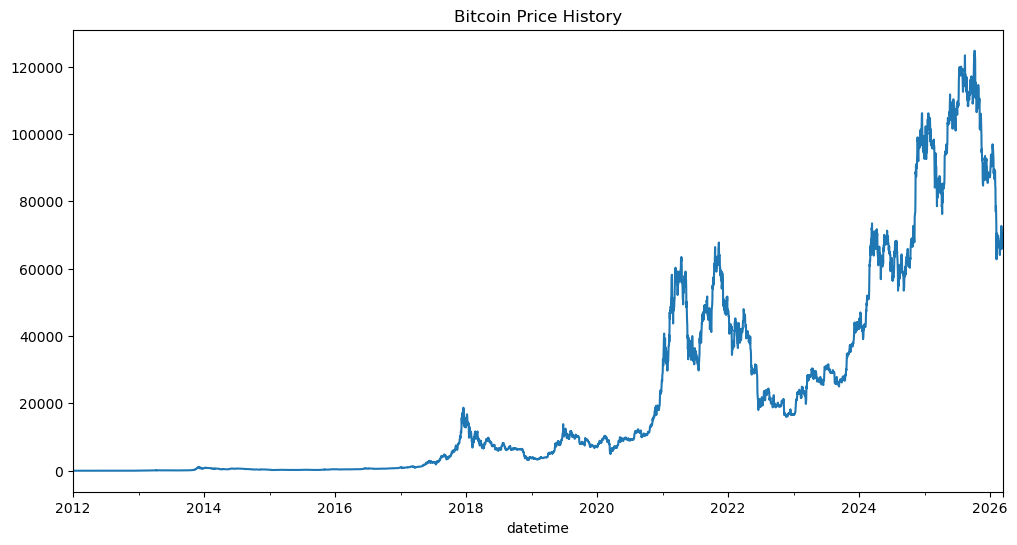

In [31]:
# Plot Quick Sanity Check

import matplotlib.pyplot as plt

btc_daily["Close"].plot(figsize=(12,6))
plt.title("Bitcoin Price History")
plt.show()